In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

In [2]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape to (28,28,1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

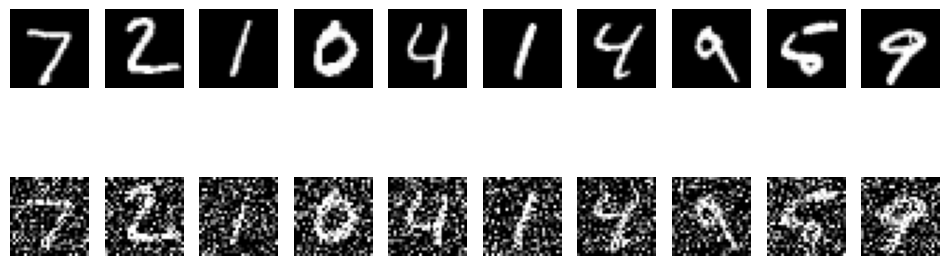

In [4]:
plt.figure(figsize=(12,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [5]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 147ms/step - loss: 0.0974 - val_loss: 0.0966
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.0970 - val_loss: 0.0963
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - loss: 0.0966 - val_loss: 0.0959
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - loss: 0.0963 - val_loss: 0.0957
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - loss: 0.0960 - val_loss: 0.0955
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.0958 - val_loss: 0.0955
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - loss: 0.0956 - val_loss: 0.0952
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.0954 - val_loss: 0.0948
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - loss: 0.0952 - val_loss: 0.0948
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - loss: 0.0950 - val_loss: 0.0945
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.0949 - val_loss: 0.0945
Epoch 12/20
469/469

In [11]:
autoencoder.save("mnist_denoising_autoencoder.keras")
print("Model saved successfully!")

Model saved successfully!


In [12]:
loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print("Test Loss:", loss)

Test Loss: 0.09386452287435532


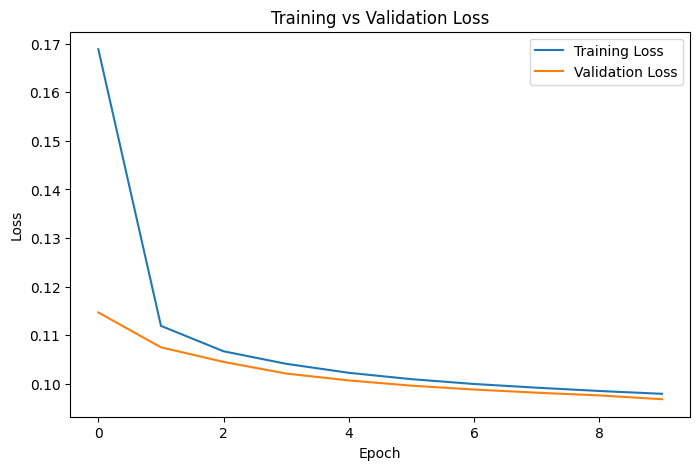

In [7]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


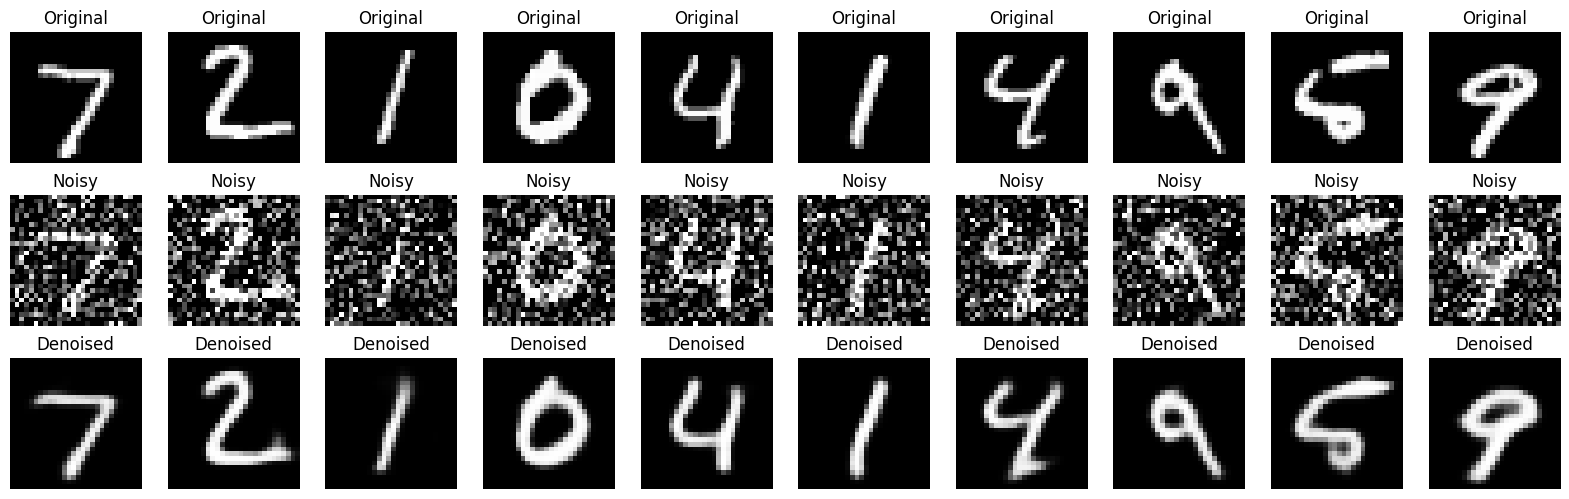

In [9]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()

Results


1. Successfully loaded and preprocessed the MNIST dataset.
2. Added Gaussian noise to simulate corrupted images.
3. Trained a Convolutional Denoising Autoencoder.
4. Generated denoised images from noisy inputs.
5. Compared Original, Noisy, and Reconstructed images.
6. Observed a decrease in both training and validation loss during training.

# Conclusion

A Convolutional Denoising Autoencoder was successfully developed to remove Gaussian noise from MNIST handwritten digit images.

The model learned meaningful latent representations of the noisy images and reconstructed cleaner versions of the original digits. The reduction in training and validation loss throughout training indicates that the model learned the denoising task effectively.

The reconstructed images preserved the overall digit structure while removing a significant amount of noise, demonstrating the effectiveness of autoencoders for image restoration tasks.